# Machine Learning Analysis

This notebook contains the machine learning models, evaluations, and comparisons used in the project. The goal is to examine whether celebrity attention metrics can help predict stock related movements 

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix
)

# Kanye West – Adidas

In [148]:
kanye_df = pd.read_csv(
    "/Users/kaanadaleti/Desktop/dsa_proje/adidas_kanye_yeezy_trends.csv"
)

kanye_df.head()


,Time,Kanye West,ADIDAS,Yeezy
0,2022-08-31,6,45,1
1,2022-09-01,7,43,1
2,2022-09-02,12,44,1
3,2022-09-03,12,50,1
4,2022-09-04,13,53,1


In [149]:
kanye_df["K_norm"] = (
    kanye_df["Kanye West"]
    / kanye_df["Kanye West"].max()
)

kanye_df["S_norm"] = (
    kanye_df["ADIDAS"]
    / kanye_df["ADIDAS"].max()
)

In [150]:
kanye_df["Return"] = (
    kanye_df["S_norm"].pct_change()
)

kanye_df["Direction"] = (
    kanye_df["Return"] > 0
).astype(int)

kanye_df = kanye_df.dropna()

In [151]:
X = kanye_df[["K_norm"]]

y_reg = kanye_df["Return"]

y_class = kanye_df["Direction"]

In [152]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_class,
    test_size=0.3,
    random_state=42
)

In [153]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()

lin_model.fit(X, y_reg)

print("Coefficient:", lin_model.coef_[0])
print("Intercept:", lin_model.intercept_)
print("R^2:", lin_model.score(X, y_reg))

Coefficient: -0.009906541327373607
Intercept: 0.006355168224066441
R^2: 0.00023947694785464435


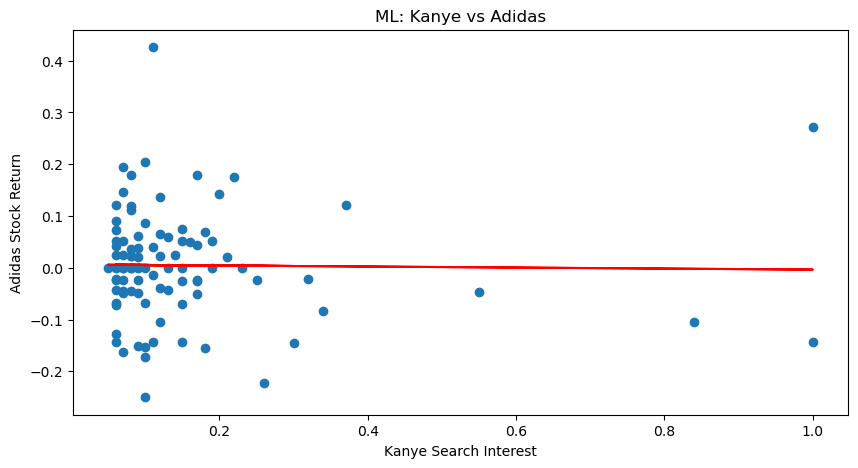

In [154]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.scatter(X, y_reg)

plt.plot(X, lin_model.predict(X), color="red")

plt.xlabel("Kanye Search Interest")
plt.ylabel("Adidas Stock Return")

plt.title("ML: Kanye vs Adidas")

plt.show()

In [155]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print(
    "Logistic Regression Accuracy:",
    accuracy_score(y_test, log_pred)
)

Logistic Regression Accuracy: 0.35714285714285715


In [156]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print(
    "Decision Tree Accuracy:",
    accuracy_score(y_test, tree_pred)
)

Decision Tree Accuracy: 0.5357142857142857


In [157]:
print(
    "Feature Importance:",
    tree_model.feature_importances_
)

Feature Importance: [1.]


## Interpretation

The Kanye West case demonstrates very weak predictive power between celebrity attention and Adidas stock returns.

Linear regression results show an extremely low explanatory power (R2 =  0.0002), indicating almost no stable linear relationship between search interest and stock return behavior.

The negative regression coefficient suggests that increases in celebrity attention are not associated with positive stock performance during the analyzed period.

Classification models also produce limited predictive success, implying that controversy driven public attention is highly noisy and difficult to model consistently.

# Sydney Sweeney – American Eagle

In [158]:
sydney_df = pd.read_csv("/Users/kaanadaleti/Desktop/dsa_proje/SydneyAmerican.csv")

sydney_df.head()

,Time,American Eagle,Sydney Sweeney
0,2025-05-25,16,24
1,2025-06-01,14,29
2,2025-06-08,14,32
3,2025-06-15,15,21
4,2025-06-22,16,16


In [159]:
print(sydney_df.columns)

Index(['Time', 'American Eagle', 'Sydney Sweeney'], dtype='object')


In [160]:
sydney_df["S_norm"] = (
    sydney_df["Sydney Sweeney"]
    / sydney_df["Sydney Sweeney"].max()
)

sydney_df["AE_norm"] = (
    sydney_df["American Eagle"]
    / sydney_df["American Eagle"].max()
)

In [161]:
sydney_df["Return"] = (
    sydney_df["AE_norm"].pct_change()
)

sydney_df["Direction"] = (
    sydney_df["Return"] > 0
).astype(int)

sydney_df = sydney_df.dropna()

In [162]:
X_sydney = sydney_df[["S_norm"]]

y_reg_sydney = sydney_df["Return"]

y_class_sydney = sydney_df["Direction"]

In [163]:
from sklearn.linear_model import LinearRegression

lin_model_sydney = LinearRegression()

lin_model_sydney.fit(
    X_sydney,
    y_reg_sydney
)

print(
    "Coefficient:",
    lin_model_sydney.coef_[0]
)

print(
    "Intercept:",
    lin_model_sydney.intercept_
)

print(
    "R^2:",
    lin_model_sydney.score(
        X_sydney,
        y_reg_sydney
    )
)

Coefficient: 0.9163736132290878
Intercept: -0.21507190566633955
R^2: 0.2592601946309281


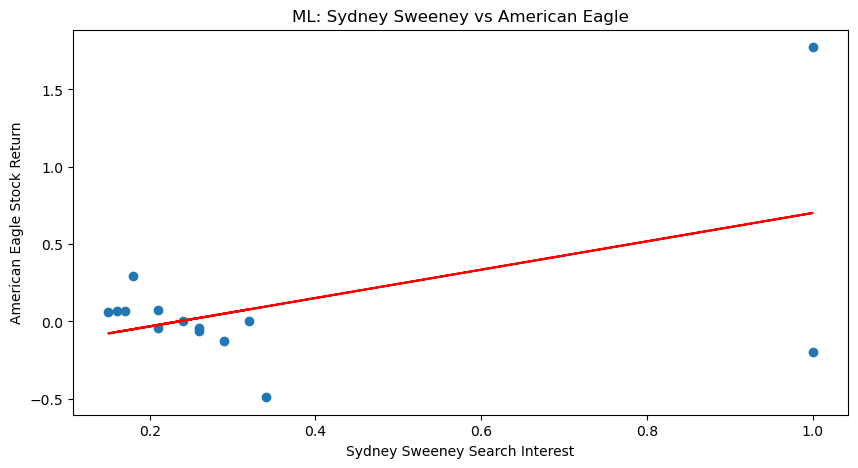

In [164]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.scatter(
    X_sydney,
    y_reg_sydney
)

plt.plot(
    X_sydney,
    lin_model_sydney.predict(X_sydney),
    color="red"
)

plt.xlabel(
    "Sydney Sweeney Search Interest"
)

plt.ylabel(
    "American Eagle Stock Return"
)

plt.title(
    "ML: Sydney Sweeney vs American Eagle"
)

plt.show()

In [165]:
from sklearn.model_selection import train_test_split

X_train_sydney, X_test_sydney, y_train_sydney, y_test_sydney = train_test_split(
    X_sydney,
    y_class_sydney,
    test_size=0.3,
    random_state=42
)

In [166]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model_sydney = LogisticRegression()

log_model_sydney.fit(
    X_train_sydney,
    y_train_sydney
)

log_pred_sydney = log_model_sydney.predict(
    X_test_sydney
)

print(
    "Logistic Regression Accuracy:",
    accuracy_score(
        y_test_sydney,
        log_pred_sydney
    )
)

Logistic Regression Accuracy: 0.2


In [167]:
from sklearn.tree import DecisionTreeClassifier

tree_model_sydney = DecisionTreeClassifier(
    random_state=42
)

tree_model_sydney.fit(
    X_train_sydney,
    y_train_sydney
)

tree_pred_sydney = tree_model_sydney.predict(
    X_test_sydney
)

print(
    "Decision Tree Accuracy:",
    accuracy_score(
        y_test_sydney,
        tree_pred_sydney
    )
)

Decision Tree Accuracy: 0.6


In [168]:
print(
    "Feature Importance:",
    tree_model_sydney.feature_importances_
)

Feature Importance: [1.]


## Interpretation

The Sydney Sweeney case demonstrates a moderate positive relationship between celebrity attention and American Eagle stock return behavior.

Linear regression results show a positive coefficient and a moderate explanatory power (R² ≈ 0.26), suggesting that increases in public attention may contribute to short-term positive stock-related movement.

While Logistic Regression performs poorly in predicting directional changes, the Decision Tree model achieves relatively better accuracy, indicating the presence of nonlinear or unstable short-term patterns.

Overall, the Sydney case shows a more structured relationship compared to the Kanye West case.

# Tiger Woods – Nike

In [169]:
tiger_df = pd.read_csv("/Users/kaanadaleti/Desktop/dsa_proje/tigerwoods.csv")

tiger_df.head()

,Time,Tiger Woods,Nike
0,2009-09-27,2,30
1,2009-10-04,2,29
2,2009-10-11,2,29
3,2009-10-18,1,30
4,2009-10-25,1,29


In [170]:
print(tiger_df.columns)

Index(['Time', 'Tiger Woods', 'Nike'], dtype='object')


In [171]:
tiger_df["T_norm"] = (
    tiger_df["Tiger Woods"]
    / tiger_df["Tiger Woods"].max()
)

tiger_df["N_norm"] = (
    tiger_df["Nike"]
    / tiger_df["Nike"].max()
)

In [172]:
tiger_df["Return"] = (
    tiger_df["N_norm"].pct_change()
)

tiger_df["Direction"] = (
    tiger_df["Return"] > 0
).astype(int)

tiger_df = tiger_df.dropna()

In [173]:
X_tiger = tiger_df[["T_norm"]]

y_reg_tiger = tiger_df["Return"]

y_class_tiger = tiger_df["Direction"]

In [174]:
from sklearn.linear_model import LinearRegression

lin_model_tiger = LinearRegression()

lin_model_tiger.fit(
    X_tiger,
    y_reg_tiger
)

print(
    "Coefficient:",
    lin_model_tiger.coef_[0]
)

print(
    "Intercept:",
    lin_model_tiger.intercept_
)

print(
    "R^2:",
    lin_model_tiger.score(
        X_tiger,
        y_reg_tiger
    )
)

Coefficient: 0.038624770678778016
Intercept: -0.01074557219301238
R^2: 0.05041216221176159


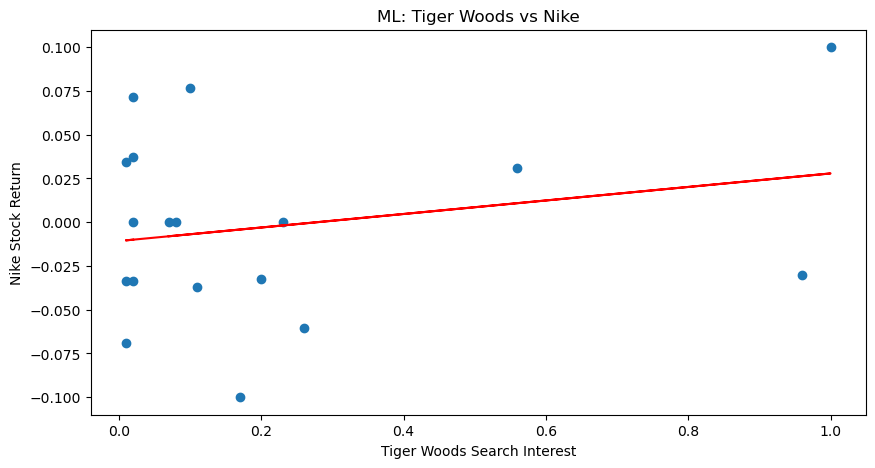

In [175]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.scatter(
    X_tiger,
    y_reg_tiger
)

plt.plot(
    X_tiger,
    lin_model_tiger.predict(X_tiger),
    color="red"
)

plt.xlabel(
    "Tiger Woods Search Interest"
)

plt.ylabel(
    "Nike Stock Return"
)

plt.title(
    "ML: Tiger Woods vs Nike"
)

plt.show()

In [176]:
from sklearn.model_selection import train_test_split

X_train_tiger, X_test_tiger, y_train_tiger, y_test_tiger = train_test_split(
    X_tiger,
    y_class_tiger,
    test_size=0.3,
    random_state=42
)

In [177]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model_tiger = LogisticRegression()

log_model_tiger.fit(
    X_train_tiger,
    y_train_tiger
)

log_pred_tiger = log_model_tiger.predict(
    X_test_tiger
)

print(
    "Logistic Regression Accuracy:",
    accuracy_score(
        y_test_tiger,
        log_pred_tiger
    )
)

Logistic Regression Accuracy: 0.6666666666666666


In [178]:
from sklearn.tree import DecisionTreeClassifier

tree_model_tiger = DecisionTreeClassifier(
    random_state=42
)

tree_model_tiger.fit(
    X_train_tiger,
    y_train_tiger
)

tree_pred_tiger = tree_model_tiger.predict(
    X_test_tiger
)

print(
    "Decision Tree Accuracy:",
    accuracy_score(
        y_test_tiger,
        tree_pred_tiger
    )
)

Decision Tree Accuracy: 0.5


In [179]:
print(
    "Feature Importance:",
    tree_model_tiger.feature_importances_
)

Feature Importance: [1.]


## Interpretation

The Tiger Woods case demonstrates a weak but observable relationship between celebrity attention and Nike stock return behavior.

Linear regression results show a small positive coefficient with low explanatory power (R2 = 0.05), indicating that public attention may have a limited influence on stock related movement.

Interestingly, Logistic Regression achieves relatively higher classification accuracy compared to the other cases, suggesting that short-term directional movement may be partially predictable even when the overall linear relationship remains weak.

Overall, the Tiger Woods case reflects moderate short term co-movement rather than a strong predictive relationship.

# Cross-Case ML Model Comparison

In [180]:
import pandas as pd

comparison_df = pd.DataFrame({

    "Case": [
        "Kanye West - Adidas",
        "Sydney Sweeney - American Eagle",
        "Tiger Woods - Nike"
    ],

    "Linear Regression R^2": [
        0.000239,
        0.259260,
        0.050412
    ],

    "Logistic Regression Accuracy": [
        0.357,
        0.200,
        0.667
    ],

    "Decision Tree Accuracy": [
        0.536,
        0.600,
        0.500
    ]

})

comparison_df

,Case,Linear Regression R^2,Logistic Regression Accuracy,Decision Tree Accuracy
0,Kanye West - Adidas,0.000239,0.357,0.536
1,Sydney Sweeney - American Eagle,0.259260,0.200,0.600
2,Tiger Woods - Nike,0.050412,0.667,0.500


## Cross-Case Interpretation

The comparison results reveal substantial differences between the analyzed celebrity-brand relationships.

Among all cases, the Sydney Sweeney – American Eagle case demonstrates the strongest linear relationship between celebrity attention and stock return behavior, achieving the highest R2 value (0.26). This suggests a more structured and measurable spillover effect between public attention and associated financial movement.

The Kanye West – Adidas case shows almost no stable predictive relationship despite large spikes in public attention. The extremely low R2 value indicates that controversy driven attention may generate noisy and unstable financial reactions that are difficult to model consistently.

The Tiger Woods – Nike case exhibits weak explanatory power in linear regression but achieves the highest Logistic Regression accuracy. This suggests that while the magnitude of stock returns may not be strongly predictable, short term directional movement may still contain partially learnable patterns.

Overall, the findings indicate that the financial and public impact of celebrity controversies varies significantly depending on the type of celebrity, the structure of the controversy, and the associated brand relationship.